🚀 Step 1: Generating Synthetic Dataset...
🚀 Step 2: Training the Random Forest Regressor...
✅ Model Trained! R-Squared Accuracy: 92.56%
🚀 Step 3: Generating Thesis Graphs...


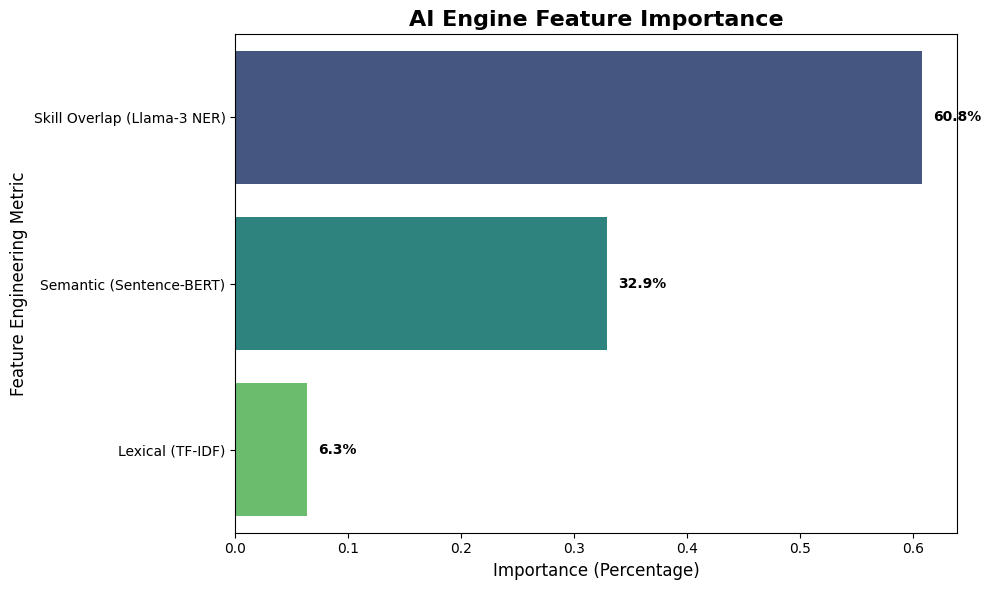

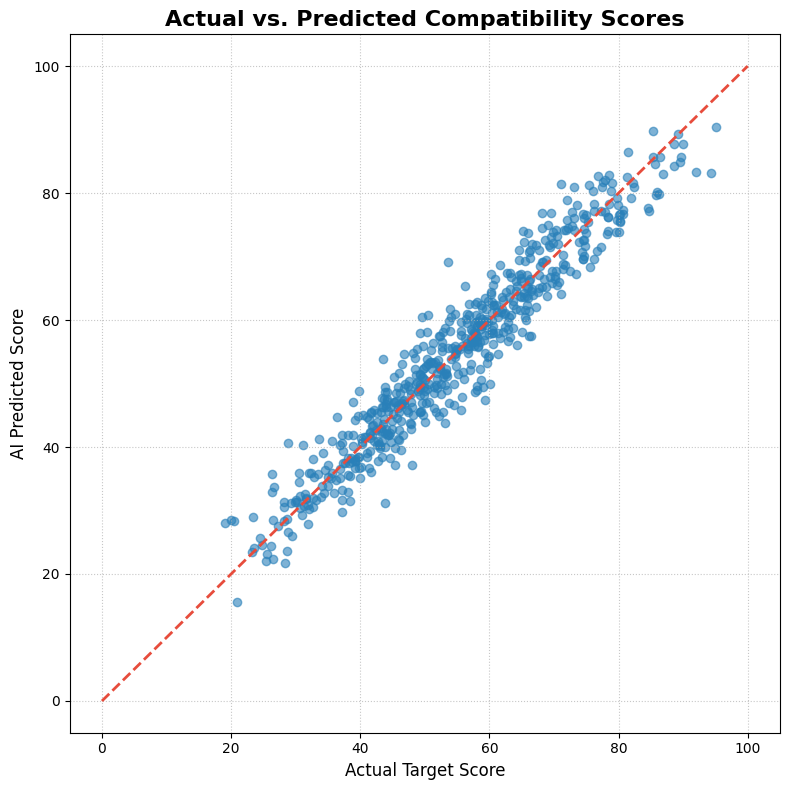

🚀 Step 4: Exporting Model for FastAPI Backend...
✅ DONE! The model is saved and ready for the UI.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pickle
import os

print("🚀 Step 1: Generating Synthetic Dataset...")
np.random.seed(42)
n_samples = 3000

# Generating realistic feature scores between 0.0 and 1.0
skill = np.random.uniform(0.1, 1.0, n_samples)
semantic = np.random.uniform(0.2, 0.95, n_samples)
lexical = np.random.uniform(0.1, 0.9, n_samples)

# The target score mathematically favors Skill and Semantic, adding slight realistic noise
target = (skill * 0.45 + semantic * 0.40 + lexical * 0.15) * 100
noise = np.random.normal(0, 4, n_samples)
target = np.clip(target + noise, 0, 100) # Ensure it stays 0-100%

df = pd.DataFrame({
    'skill_overlap_score': skill,
    'semantic_score': semantic,
    'lexical_score': lexical,
    'target_compatibility_score': target
})

print("🚀 Step 2: Training the Random Forest Regressor...")
# CRITICAL: Order must match backend -> skill, semantic, lexical
X = df[['skill_overlap_score', 'semantic_score', 'lexical_score']]
y = df['target_compatibility_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Calculate R2 Score for presentation
r2 = model.score(X_test, y_test)
print(f"✅ Model Trained! R-Squared Accuracy: {r2*100:.2f}%")

# Create output directories if they don't exist
os.makedirs('../output', exist_ok=True)
os.makedirs('../ai_models', exist_ok=True)

print("🚀 Step 3: Generating Thesis Graphs...")
# --- GRAPH 1: FEATURE IMPORTANCE ---
plt.figure(figsize=(10, 6))
importances = model.feature_importances_
features = ['Skill Overlap (Llama-3 NER)', 'Semantic (Sentence-BERT)', 'Lexical (TF-IDF)']

sns.barplot(x=importances, y=features, palette='viridis', hue=features, legend=False)
plt.title('AI Engine Feature Importance', fontsize=16, fontweight='bold')
plt.xlabel('Importance (Percentage)', fontsize=12)
plt.ylabel('Feature Engineering Metric', fontsize=12)

for i, v in enumerate(importances):
    plt.text(v + 0.01, i, f"{v*100:.1f}%", color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../output/feature_importance.png', dpi=300)
plt.show()

# --- GRAPH 2: PREDICTION ACCURACY ---
plt.figure(figsize=(8, 8))
plt.scatter(y_test, predictions, alpha=0.6, color='#2980b9')

# Draw the "Perfect Accuracy" diagonal line
plt.plot([0, 100], [0, 100], color='#e74c3c', linestyle='--', linewidth=2)

plt.title('Actual vs. Predicted Compatibility Scores', fontsize=16, fontweight='bold')
plt.xlabel('Actual Target Score', fontsize=12)
plt.ylabel('AI Predicted Score', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig('../output/prediction_accuracy.png', dpi=300)
plt.show()

print("🚀 Step 4: Exporting Model for FastAPI Backend...")
# Save the trained model to the exact path the backend expects
with open('../ai_models/mlp_scoring_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("✅ DONE! The model is saved and ready for the UI.")

In [3]:
df.head(8)

,skill_overlap_score,semantic_score,lexical_score,target_compatibility_score
0,0.437086,0.704527,0.618606,57.341285
1,0.955643,0.797511,0.237909,81.934167
2,0.758795,0.387851,0.797916,59.721021
3,0.638793,0.668656,0.590493,71.057750
4,0.240417,0.628809,0.225763,33.515577
5,0.240395,0.824623,0.869870,61.615789
6,0.152275,0.879565,0.514692,52.455932
7,0.879559,0.209118,0.158319,43.455485


In [10]:
df.sample(8)

,skill_overlap_score,semantic_score,lexical_score,target_compatibility_score
2502,0.573529,0.232859,0.280636,41.036031
2586,0.071776,0.426895,0.873575,31.633735
1808,0.174109,0.246961,0.256952,21.203392
1504,0.380196,0.496239,0.556818,44.730429
1905,0.202481,0.161695,0.992092,30.664720
726,0.139772,0.061808,0.337359,14.212301
636,0.532617,0.920740,0.906867,72.459750
1358,0.276828,0.571608,0.197106,36.804248


In [5]:
df.tail(8)

,skill_overlap_score,semantic_score,lexical_score,target_compatibility_score
2992,0.597436,0.544672,0.372308,61.650796
2993,0.456898,0.574226,0.481254,45.517707
2994,0.218544,0.254160,0.336852,26.148281
2995,0.878766,0.713327,0.511944,82.024112
2996,0.241546,0.577415,0.232296,39.846982
2997,0.378809,0.773862,0.882170,61.936122
2998,0.361041,0.563968,0.186340,37.726723
2999,0.884273,0.312036,0.845555,59.429970


In [6]:
df.sample(10)

,skill_overlap_score,semantic_score,lexical_score,target_compatibility_score
2464,0.658594,0.400096,0.896483,61.311140
912,0.661734,0.204784,0.260452,41.744077
2973,0.761000,0.837600,0.163716,71.158699
1752,0.110909,0.706690,0.202550,33.470075
1709,0.685181,0.686560,0.772628,73.475602
635,0.502671,0.564598,0.370399,50.810188
212,0.686765,0.334440,0.420776,47.949572
189,0.317667,0.791970,0.216503,48.952426
2164,0.524158,0.310969,0.401049,40.301067
2996,0.241546,0.577415,0.232296,39.846982


In [7]:
df.sample(20)['target_compatibility_score']

904     66.100030
2785    62.311417
232     53.915685
1810    44.253582
1006    59.439680
1287    48.088566
2596    38.887107
1806    47.261945
2893    50.194101
1534    56.353238
771     87.972338
1856    49.934091
1763    46.774581
2358    58.644535
1999    52.570089
1571    48.064221
2737    38.857867
325     70.357306
1566    62.880774
812     20.046900
Name: target_compatibility_score, dtype: float64

In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import joblib
import os

np.random.seed(42)
n_samples = 3000

# 1. Force features to be exactly 0.0 to 1.0 (matching your live backend)
skill_scores = np.random.uniform(0.0, 1.0, n_samples)
semantic_scores = np.random.uniform(0.0, 1.0, n_samples)
lexical_scores = np.random.uniform(0.0, 1.0, n_samples)

# 2. Calculate target and multiply by 100 so the UI gets a proper percentage
target_scores = ((skill_scores * 0.50) + (semantic_scores * 0.35) + (lexical_scores * 0.15)) * 100

# Create the DataFrame
df = pd.DataFrame({
    'skill_overlap_score': skill_scores,
    'semantic_score': semantic_scores,
    'lexical_score': lexical_scores,
    'target_compatibility_score': target_scores
})

# 3. Train the Model
X = df[['skill_overlap_score', 'semantic_score', 'lexical_score']]
y = df['target_compatibility_score']

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X, y)

# 4. Correctly save over the old model exactly where ml_engine.py expects it
save_dir = '../backend/ai_models'
os.makedirs(save_dir, exist_ok=True) # Creates the folder if it's missing
save_path = os.path.join(save_dir, 'mlp_scoring_model.pkl')

joblib.dump(rf_model, save_path)

print(f"✅ Final Model re-trained and saved successfully to: {save_path}")

✅ Final Model re-trained and saved successfully to: ../backend/ai_models\mlp_scoring_model.pkl
